<div dir="rtl" style="text-align: right">

‏# 02 — مهندسی ویژگی پیشرفته

</div>

In [ ]:
# Persian text rendering for notebook markdown and plots
import matplotlib as mpl

mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": [
        "Vazirmatn",
        "Vazir",
        "IRANSans",
        "Noto Sans Arabic",
        "Noto Naskh Arabic",
        "DejaVu Sans",
    ],
    "axes.unicode_minus": False,
})

try:
    from IPython.display import HTML, display

    display(HTML('<div dir="rtl" style="text-align: right"></div>'))
except Exception:
    pass

<div dir="rtl" style="text-align: right">

‏<style>
‏/* Improve RTL readability for notebook markdown in JupyterLab/classic */
‏.jp-RenderedMarkdown,
‏.rendered_html,
‏div.text_cell_render,
‏div.output_area,
‏.jp-MarkdownOutput {
‏  direction: rtl;
‏  text-align: right;
‏}

‏.jp-RenderedMarkdown table,
‏.rendered_html table,
‏div.text_cell_render table {
‏  direction: rtl;
‏  text-align: right;
‏}

‏.jp-RenderedMarkdown li,
‏.rendered_html li,
‏div.text_cell_render li {
‏  margin-right: 1.2em;
‏}
‏</style>

</div>

<div dir="rtl" style="text-align: right">

‏## Concept: categorical features without target leakage

‏CatBoost is not the first model we will try, but its core idea is useful for understanding why feature engineering can go wrong.

‏### CatBoost workflow at a glance

‏![CatBoost workflow: raw mixed features are permuted, converted into leakage-safe ordered category statistics, processed by sequential trees, and converted into a probability and thresholded prediction.](../assets/catboost_workflow.png)

‏Read the upper path from left to right. The lower inset isolates the central safety idea: naive target encoding calculates a category rate using every label, including the current row. Ordered statistics use only labels from earlier rows in a permutation. The illustrated numbers are pedagogical examples, not values calculated from the Bank Marketing dataset.

</div>

In [1]:
import hashlib, json, os, platform, random
from pathlib import Path
ROOT = Path.cwd()
if not (ROOT / "data").exists() and (ROOT.parent / "data").exists():
    ROOT = ROOT.parent
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (confusion_matrix, log_loss,
                             precision_score, recall_score)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

SEED = 42
TARGET = "y"
LEAKAGE_COLUMNS = ["duration"]

def project_root():
    # اگر ریشه دوره در دسترس بود همان را برگردان، وگرنه پوشه دفترچه را.
    return ROOT

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)

def fast_mode():
    # برای آزمایش‌های کامل، FAST_MODE=0 را تنظیم کنید؛ حالت لپ‌تاپ به‌صورت پیش‌فرض فعال است.
    return os.getenv("FAST_MODE", "1").lower() not in {"0", "false", "no"}

def bank_data_path():
    # این دوره با یک مجموعه‌داده محلی همراه است؛ دفترچه‌ها هرگز به شبکه دسترسی ندارند.
    path = project_root() / "data" / "raw" / "bank-full.csv"
    if not path.is_file():
        raise FileNotFoundError(
            f"Expected the bundled Bank Marketing data at {path}. "
            "Run the notebook from the course root or place bank-full.csv there."
        )
    return path

def file_sha256(path):
    digest = hashlib.sha256()
    with Path(path).open("rb") as handle:
        for chunk in iter(lambda: handle.read(1 << 20), b""):
            digest.update(chunk)
    return digest.hexdigest()

def load_bank_data(include_duration=False):
    # داده را بارگذاری کن، y را encode کن، و مدت تماس پس از تماس را به‌صورت پیش‌فرض حذف کن.
    frame = pd.read_csv(bank_data_path(), sep=";")
    frame[TARGET] = frame[TARGET].map({"no": 0, "yes": 1}).astype("int8")
    if not include_duration:
        frame = frame.drop(columns=LEAKAGE_COLUMNS)
    return frame

def stratified_sample(frame, n, seed=SEED):
    if n >= len(frame):
        return frame.copy()
    fractions = frame[TARGET].value_counts(normalize=True)
    counts = (fractions * n).round().astype(int)
    counts.iloc[0] += n - counts.sum()
    parts = [group.sample(n=min(counts.loc[label], len(group)),
                          random_state=seed + int(label))
             for label, group in frame.groupby(TARGET)]
    return pd.concat(parts).sample(frac=1, random_state=seed).reset_index(drop=True)

def make_splits(frame=None, reduced=None):
    # split قطعی و stratified به نسبت 60/20/20؛ مجموعه آزمون تا دفترچه 09 قفل می‌ماند.
    from sklearn.model_selection import train_test_split
    frame = load_bank_data() if frame is None else frame
    train_val, test = train_test_split(
        frame, test_size=0.20, stratify=frame[TARGET], random_state=SEED)
    train, validation = train_test_split(
        train_val, test_size=0.25, stratify=train_val[TARGET], random_state=SEED)
    reduced = fast_mode() if reduced is None else reduced
    if reduced:
        train = stratified_sample(train, 12_000)
        validation = stratified_sample(validation, 4_000, SEED + 1)
        test = stratified_sample(test, 4_000, SEED + 2)
    return tuple(part.reset_index(drop=True) for part in (train, validation, test))

def split_xy(frame):
    return frame.drop(columns=TARGET), frame[TARGET]

def feature_groups(frame):
    features = frame.drop(columns=[TARGET], errors="ignore")
    categorical = features.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
    numerical = features.select_dtypes(include=np.number).columns.tolist()
    return numerical, categorical

def make_preprocessor(frame, scale_numeric=True):
    # preprocessing فقط داخل pipeline آموزش/CV مربوطه fit می‌شود.
    numerical, categorical = feature_groups(frame)
    numeric_steps = [("impute", SimpleImputer(strategy="median"))]
    if scale_numeric:
        numeric_steps.append(("scale", StandardScaler()))
    categorical_pipe = Pipeline([
        ("impute", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="infrequent_if_exist",
                                 min_frequency=10, sparse_output=True)),
    ])
    return ColumnTransformer([
        ("numeric", Pipeline(numeric_steps), numerical),
        ("categorical", categorical_pipe, categorical),
    ], sparse_threshold=0.3)

def classification_metrics(y_true, probability, threshold=0.5):
    prediction = np.asarray(probability) >= threshold
    tn, fp, fn, tp = confusion_matrix(y_true, prediction, labels=[0, 1]).ravel()
    return {"log_loss": log_loss(y_true, probability),
            "precision": precision_score(y_true, prediction, zero_division=0),
            "recall": recall_score(y_true, prediction, zero_division=0),
            "specificity": tn / (tn + fp) if (tn + fp) else np.nan,
            "cost": float(fp + 5 * fn)}

def threshold_table(y_true, probability, thresholds=None):
    thresholds = np.linspace(0.05, 0.80, 76) if thresholds is None else thresholds
    return pd.DataFrame([{"threshold": float(t),
                          **classification_metrics(y_true, probability, float(t))}
                         for t in thresholds])

def add_domain_features(frame):
    result = frame.copy()
    result["was_previously_contacted"] = (result["pdays"] != -1).astype("int8")
    result["pdays_clean"] = result["pdays"].replace(-1, np.nan)
    result["contact_pressure"] = result["campaign"] / (1 + result["previous"])
    result["balance_per_age"] = result["balance"] / result["age"].clip(lower=18)
    result["age_band"] = pd.cut(result["age"], bins=[0, 29, 39, 49, 59, np.inf],
                                labels=["<30", "30s", "40s", "50s", "60+"]).astype("object")
    return result.drop(columns=["pdays"])

def environment_metadata():
    import sklearn
    return {"python": platform.python_version(), "platform": platform.platform(),
            "numpy": np.__version__, "pandas": pd.__version__,
            "scikit_learn": sklearn.__version__}

def write_json(data, path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_text(json.dumps(data, indent=2, sort_keys=True), encoding="utf-8")

set_seed(SEED)
FAST_MODE = fast_mode()
CV_FOLDS = 3 if FAST_MODE else 5
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 30)
print({"FAST_MODE": FAST_MODE, "CV_FOLDS": CV_FOLDS, "seed": SEED})

{'FAST_MODE': True, 'CV_FOLDS': 3, 'seed': 42}


In [2]:
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, balanced_accuracy_score,
                             precision_score, recall_score, f1_score)

bank = load_bank_data()
development, validation, _sealed_test = make_splits(bank, reduced=FAST_MODE)
X_dev, y_dev = split_xy(development)
X_val, y_val = split_xy(validation)
cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=SEED)
CV_SPLITS = list(cv.split(X_dev, y_dev))

split_summary = pd.DataFrame({
    "rows": [len(development), len(validation)],
    "positive_rate": [y_dev.mean(), y_val.mean()],
}, index=["development", "validation"])
display(split_summary.style.format({"positive_rate": "{:.1%}"}))
print(f"loaded {bank.shape[0]:,} rows and {bank.shape[1] - 1} pre-contact features")

,rows,positive_rate
development,12000,11.7%
validation,4000,11.7%


loaded 45,211 rows and 15 pre-contact features


<div dir="rtl" style="text-align: right">

‏## ممیزی داده

</div>

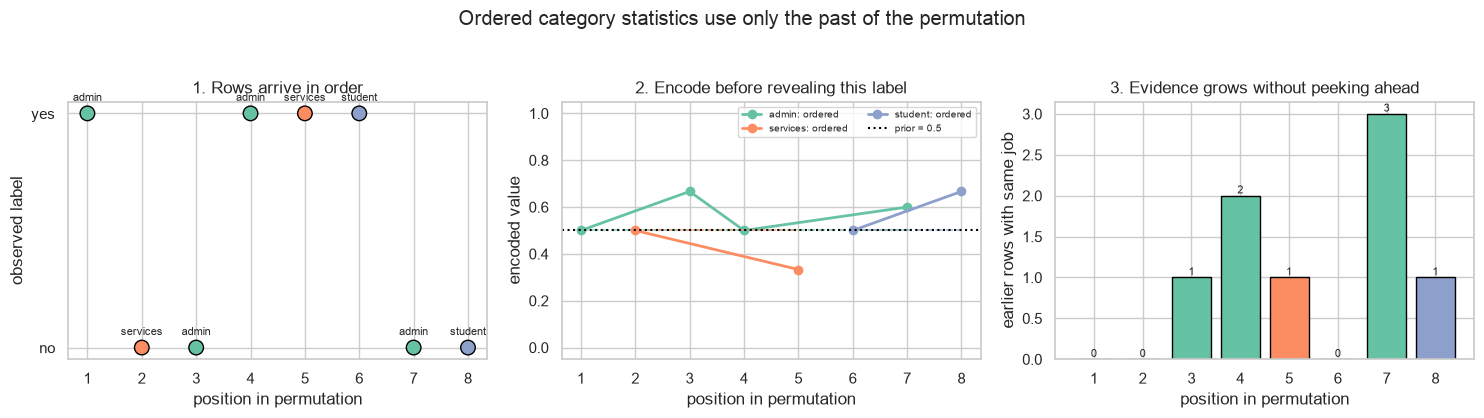

,step,job,subscribed,ordered_stat,earlier_same_job_rows,naive_full_data_stat
0,1,admin,1,0.500,0,0.5
1,2,services,0,0.500,0,0.5
2,3,admin,0,0.667,1,0.5
3,4,admin,1,0.500,2,0.5
4,5,services,1,0.333,1,0.5
5,6,student,1,0.500,0,0.5
6,7,admin,0,0.600,3,0.5
7,8,student,0,0.667,1,0.5


In [3]:
toy_order = pd.DataFrame({
    "step": np.arange(1, 9),
    "job": ["admin", "services", "admin", "admin",
            "services", "student", "admin", "student"],
    "subscribed": [1, 0, 0, 1, 1, 1, 0, 0],
})
prior, prior_weight = 0.5, 2.0
category_sums, category_counts = {}, {}
ordered_values, histories = [], []
for row in toy_order.itertuples(index=False):
    previous_sum = category_sums.get(row.job, 0)
    previous_count = category_counts.get(row.job, 0)
    ordered_values.append(
        (previous_sum + prior_weight * prior) / (previous_count + prior_weight)
    )
    histories.append(previous_count)
    category_sums[row.job] = previous_sum + row.subscribed
    category_counts[row.job] = previous_count + 1

toy_order["ordered_stat"] = ordered_values
toy_order["earlier_same_job_rows"] = histories
toy_order["naive_full_data_stat"] = toy_order.groupby("job")["subscribed"].transform("mean")
job_colors = dict(zip(toy_order["job"].unique(), sns.color_palette("Set2", 3)))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].scatter(toy_order["step"], toy_order["subscribed"], s=110,
                c=[job_colors[j] for j in toy_order["job"]], edgecolor="black")
for row in toy_order.itertuples(index=False):
    axes[0].annotate(row.job, (row.step, row.subscribed), xytext=(0, 9),
                     textcoords="offset points", ha="center", fontsize=8)
axes[0].set(xticks=toy_order["step"], yticks=[0, 1], yticklabels=["no", "yes"],
            xlabel="position in permutation", ylabel="observed label",
            title="1. Rows arrive in order")

for job, group in toy_order.groupby("job", sort=False):
    axes[1].plot(group["step"], group["ordered_stat"], marker="o", linewidth=2,
                 color=job_colors[job], label=f"{job}: ordered")
    axes[1].plot(group["step"], group["naive_full_data_stat"], linestyle="--",
                 linewidth=1.4, color=job_colors[job], alpha=0.65)
axes[1].axhline(prior, color="black", linestyle=":", label="prior = 0.5")
axes[1].set(xlabel="position in permutation", ylabel="encoded value", ylim=(-0.05, 1.05),
            title="2. Encode before revealing this label")
axes[1].legend(fontsize=7, ncol=2)

bars = axes[2].bar(toy_order["step"], toy_order["earlier_same_job_rows"],
                   color=[job_colors[j] for j in toy_order["job"]], edgecolor="black")
axes[2].bar_label(bars, fontsize=8)
axes[2].set(xticks=toy_order["step"], xlabel="position in permutation",
            ylabel="earlier rows with same job",
            title="3. Evidence grows without peeking ahead")
fig.suptitle("Ordered category statistics use only the past of the permutation", y=1.04)
plt.tight_layout()
plt.show()
display(toy_order.round(3))

<div dir="rtl" style="text-align: right">

‏## فرضیه‌های ویژگی پیش از کدنویسی

‏پیش از ساخت ویژگی جدید، مشخص می‌کنیم کدام الگوها از نظر دامنه مسئله منطقی‌اند: سابقه تماس، فشار کمپین، وضعیت مالی، و الگوهای سنی. این کار از feature engineering تصادفی جلوگیری می‌کند.

</div>

In [4]:
feature_audit = pd.DataFrame({
    "dtype": X_dev.dtypes.astype(str),
    "unique": X_dev.nunique(dropna=False),
    "missing_pct": X_dev.isna().mean().mul(100),
}).sort_values(["dtype", "unique"])
display(feature_audit)
display(pd.crosstab(X_dev["pdays"].eq(-1), y_dev, normalize="index")
        .rename(index={True: "never contacted", False: "contacted"}))

,dtype,unique,missing_pct
day,int64,31,0.0
previous,int64,33,0.0
campaign,int64,40,0.0
age,int64,74,0.0
pdays,int64,409,0.0
balance,int64,4077,0.0
default,object,2,0.0
housing,object,2,0.0
loan,object,2,0.0
marital,object,3,0.0


y,0,1
pdays,,
contacted,0.782407,0.217593
never contacted,0.905081,0.094919


<div dir="rtl" style="text-align: right">

‏## Feature hypotheses before code

‏Good feature engineering starts as a short, testable hypothesis list:

‏- `pdays=-1` mixes a missing-history state with numeric recency. Split it into an indicator and nullable recency.
‏- `campaign / (1 + previous)` approximates current contact pressure relative to known history.
‏- `balance / age` is a deliberately weak ratio hypothesis; ablation will decide whether it helps.
‏- Age bins allow nonlinearity but sacrifice local detail.

‏These are predictive transformations, not causal mechanisms. The transformer is row-wise and stateless; learned imputation, scaling, and category vocabularies remain inside the pipeline.

‏**Teaching note:** A feature that sounds plausible still has to earn its place. Extra columns increase debugging, monitoring, and deployment cost.

</div>

In [5]:
REQUIRED_FEATURE_COLUMNS = {"pdays", "campaign", "previous", "balance", "age"}

def add_domain_features(frame):
    """Create pre-contact domain features using row-wise, stateless logic."""
    missing = REQUIRED_FEATURE_COLUMNS.difference(frame.columns)
    if missing:
        raise ValueError(f"missing required columns: {sorted(missing)}")
    if frame["age"].dropna().le(0).any():
        raise ValueError("age must be positive when present")
    if frame["previous"].dropna().lt(0).any():
        raise ValueError("previous must be non-negative when present")
    result = frame.copy()

    # In this dataset, pdays=-1 means the client was never previously contacted.
    result["was_previously_contacted"] = (result["pdays"] != -1).astype("int8")
    result["pdays_clean"] = result["pdays"].replace(-1, np.nan)

    # Hypotheses to validate by ablation rather than assume useful.
    result["contact_pressure"] = result["campaign"] / (1 + result["previous"])
    result["balance_per_age"] = result["balance"] / result["age"].clip(lower=18)
    result["age_band"] = pd.cut(
        result["age"],
        bins=[0, 29, 39, 49, 59, np.inf],
        labels=["<30", "30s", "40s", "50s", "60+"],
    ).astype("object")

    return result.drop(columns=["pdays"])

In [6]:
engineered_preview = add_domain_features(X_dev.head())
engineered_preview.T

,0,1,2,3,4
age,40,56,56,31,30
job,blue-collar,management,admin.,self-employed,management
marital,married,married,divorced,single,single
education,secondary,tertiary,secondary,tertiary,tertiary
default,no,no,no,no,no
balance,271,1282,-429,283,61
housing,yes,no,no,no,yes
loan,no,no,yes,no,no
contact,unknown,cellular,cellular,cellular,telephone
day,29,19,23,28,5


<div dir="rtl" style="text-align: right">

‏## معیارها و قضاوت baseline

‏هر feature set جدید را نسبت به یک baseline روشن می‌سنجیم. اگر بهبود معنی‌دار نباشد، ویژگی‌های اضافی ممکن است فقط هزینه نگه‌داری و خطر leakage را بالا ببرند.

</div>

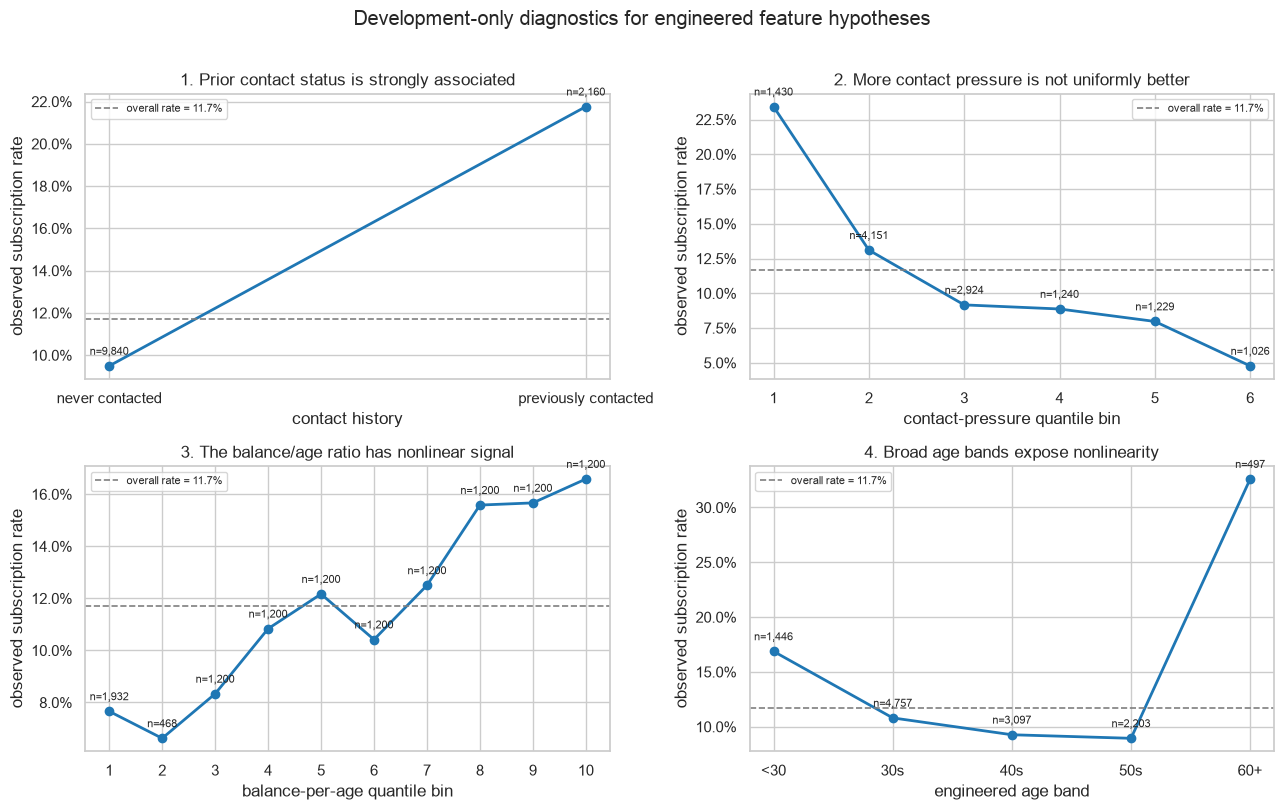

In [7]:
diagnostic = add_domain_features(X_dev).assign(target=y_dev.to_numpy())
diagnostic["contact history"] = diagnostic["was_previously_contacted"].map(
    {0: "never contacted", 1: "previously contacted"}
)
diagnostic["contact-pressure quantile bin"] = (
    pd.qcut(diagnostic["contact_pressure"], q=10, labels=False, duplicates="drop") + 1
)
diagnostic["balance-per-age quantile bin"] = (
    pd.qcut(diagnostic["balance_per_age"], q=10, labels=False, duplicates="drop") + 1
)

def plot_rate_by_group(axis, frame, group, order, title, xlabel):
    summary = (
        frame.groupby(group, observed=True)["target"]
        .agg(rate="mean", n="size")
        .reindex(order)
        .dropna()
    )
    positions = np.arange(len(summary))
    axis.plot(positions, summary["rate"], marker="o", linewidth=2, color="tab:blue")
    axis.axhline(y_dev.mean(), color="tab:gray", linestyle="--", linewidth=1.2,
                 label=f"overall rate = {y_dev.mean():.1%}")
    for position, rate, count in zip(positions, summary["rate"], summary["n"]):
        axis.annotate(f"n={count:,}", (position, rate), xytext=(0, 8),
                      textcoords="offset points", ha="center", fontsize=8)
    axis.set(xticks=positions, xticklabels=summary.index, xlabel=xlabel,
             ylabel="observed subscription rate", title=title)
    axis.yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1.0))
    axis.legend(fontsize=8, loc="best")

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
plot_rate_by_group(
    axes[0, 0], diagnostic, "contact history",
    ["never contacted", "previously contacted"],
    "1. Prior contact status is strongly associated", "contact history",
)
pressure_order = sorted(diagnostic["contact-pressure quantile bin"].dropna().unique())
plot_rate_by_group(
    axes[0, 1], diagnostic, "contact-pressure quantile bin", pressure_order,
    "2. More contact pressure is not uniformly better", "contact-pressure quantile bin",
)
balance_order = sorted(diagnostic["balance-per-age quantile bin"].dropna().unique())
plot_rate_by_group(
    axes[1, 0], diagnostic, "balance-per-age quantile bin", balance_order,
    "3. The balance/age ratio has nonlinear signal", "balance-per-age quantile bin",
)
plot_rate_by_group(
    axes[1, 1], diagnostic, "age_band", ["<30", "30s", "40s", "50s", "60+"],
    "4. Broad age bands expose nonlinearity", "engineered age band",
)
fig.suptitle("Development-only diagnostics for engineered feature hypotheses", y=1.01)
plt.tight_layout()
plt.show()

<div dir="rtl" style="text-align: right">

‏## پیش‌پردازش

</div>

In [8]:
positive_rate = y_dev.mean()
majority_accuracy = max(positive_rate, 1 - positive_rate)
print(f"positive class: {positive_rate:.1%}")
print(f"always predict 'no' accuracy: {majority_accuracy:.1%}")

positive class: 11.7%
always predict 'no' accuracy: 88.3%


<div dir="rtl" style="text-align: right">

‏## مدل‌سازی: اول baselineهای عملیِ قوی

‏ما با مدل‌های عملی و معقول شروع می‌کنیم و فقط بعد از آن سراغ روش‌های پیچیده‌تر می‌رویم.

</div>

In [9]:
def make_preprocessor(frame):
    features = frame.drop(columns=[TARGET], errors="ignore")
    categorical = features.select_dtypes(
        include=["object", "category", "bool"]
    ).columns.tolist()
    numerical = features.select_dtypes(include=np.number).columns.tolist()

    numeric_pipe = Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("scale", StandardScaler()),
    ])
    categorical_pipe = Pipeline([
        ("impute", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(
            handle_unknown="infrequent_if_exist",
            min_frequency=10,
            sparse_output=True,
        )),
    ])
    return ColumnTransformer([
        ("numeric", numeric_pipe, numerical),
        ("categorical", categorical_pipe, categorical),
    ], sparse_threshold=0.3)

<div dir="rtl" style="text-align: right">

‏## ارزیابی: cross-validation و ablation

‏cross-validation نشان می‌دهد نتایج چقدر پایدارند. ablation کمک می‌کند بفهمیم کدام گروه ویژگی واقعاً ارزش افزوده ایجاد کرده است.

</div>

In [10]:
baseline = Pipeline([
    ("preprocess", make_preprocessor(development)),
    ("model", LogisticRegression(max_iter=1200, random_state=SEED)),
])
engineered_frame = add_domain_features(development)
engineered = Pipeline([
    ("features", FunctionTransformer(add_domain_features, validate=False)),
    ("preprocess", make_preprocessor(engineered_frame)),
    ("model", LogisticRegression(max_iter=1200, random_state=SEED)),
])

fold_metrics = {}

def cv_summary(name, estimator):
    scores = cross_validate(
        estimator, X_dev, y_dev, cv=CV_SPLITS,
        scoring=["accuracy", "balanced_accuracy", "precision", "recall", "f1"],
        n_jobs=-1,
    )
    fold_metrics[name] = pd.DataFrame({
        metric: scores[f"test_{metric}"]
        for metric in ["accuracy", "balanced_accuracy", "precision", "recall", "f1"]
    }).rename_axis("fold")
    accuracy = scores["test_accuracy"]
    return {
        "experiment": name,
        "accuracy_mean": accuracy.mean(),
        "accuracy_sd": accuracy.std(ddof=1),
        "accuracy_se": accuracy.std(ddof=1) / np.sqrt(len(accuracy)),
        "balanced_accuracy": scores["test_balanced_accuracy"].mean(),
        "precision": scores["test_precision"].mean(),
        "recall": scores["test_recall"].mean(),
        "f1": scores["test_f1"].mean(),
    }

ablation = pd.DataFrame([cv_summary("raw features", baseline),
                         cv_summary("domain features", engineered)]).set_index("experiment")
ablation

,accuracy_mean,accuracy_sd,accuracy_se,balanced_accuracy,precision,recall,f1
experiment,,,,,,,
raw features,0.888083,0.000878,0.000507,0.562812,0.594400,0.138177,0.224104
domain features,0.887500,0.000661,0.000382,0.564954,0.578066,0.143875,0.230178


<div dir="rtl" style="text-align: right">

‏## اعتبارسنجی ویژگی

‏هر ویژگی جدید باید از سه زاویه بررسی شود: منطقی بودن از دید دامنه، عدم نشت اطلاعات، و اثر واقعی روی عملکرد.

</div>

,accuracy_mean,accuracy_sd,accuracy_se,balanced_accuracy,precision,recall,f1,delta_accuracy,delta_balanced_accuracy
experiment,,,,,,,,,
without demographic,0.888000,0.000866,0.000500,0.563383,0.591724,0.139601,0.225738,0.000500,-0.001571
without contact pressure,0.887667,0.000382,0.000220,0.565666,0.580050,0.145299,0.232181,0.000167,0.000712
all engineered,0.887500,0.000661,0.000382,0.564954,0.578066,0.143875,0.230178,0.000000,0.000000
without contact history,0.887250,0.000661,0.000382,0.564194,0.573329,0.142450,0.228064,-0.000250,-0.000759


,delta_accuracy,delta_balanced_accuracy,delta_recall,delta_f1
experiment,,,,
without contact history,-0.000250,-0.000759,-0.001425,-0.002113
without contact pressure,0.000167,0.000712,0.001425,0.002004
without demographic,0.000500,-0.001571,-0.004274,-0.004440


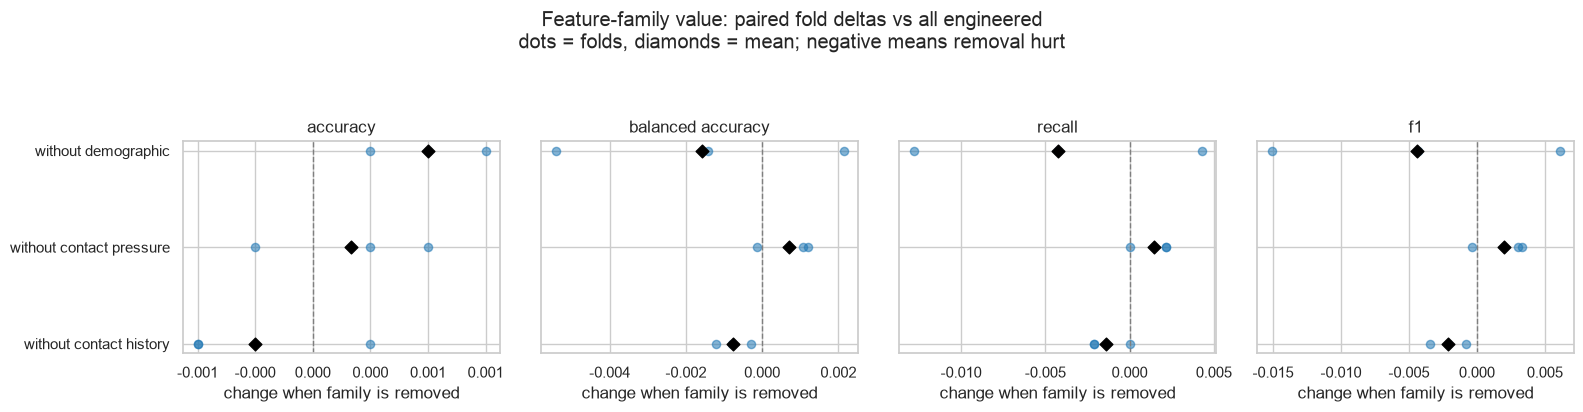

In [11]:
FEATURE_FAMILIES = {
    "contact history": ["was_previously_contacted", "pdays_clean"],
    "contact pressure": ["contact_pressure"],
    "demographic": ["balance_per_age", "age_band"],
}

def domain_features_without(frame, excluded=()):
    return add_domain_features(frame).drop(columns=list(excluded), errors="ignore")

def pipeline_without(excluded=()):
    schema = domain_features_without(development, excluded)
    transform = FunctionTransformer(
        domain_features_without, kw_args={"excluded": tuple(excluded)}, validate=False
    )
    return Pipeline([
        ("features", transform),
        ("preprocess", make_preprocessor(schema)),
        ("model", LogisticRegression(max_iter=1200, random_state=SEED)),
    ])

family_ablation = [cv_summary("all engineered", pipeline_without())]
for family, columns in FEATURE_FAMILIES.items():
    family_ablation.append(cv_summary(f"without {family}", pipeline_without(columns)))
family_ablation = pd.DataFrame(family_ablation).set_index("experiment")
family_ablation["delta_accuracy"] = (
    family_ablation["accuracy_mean"] - family_ablation.loc["all engineered", "accuracy_mean"]
)
family_ablation["delta_balanced_accuracy"] = (
    family_ablation["balanced_accuracy"]
    - family_ablation.loc["all engineered", "balanced_accuracy"]
)
display(family_ablation.sort_values("accuracy_mean", ascending=False))

all_folds = fold_metrics["all engineered"]
paired_rows = []
for experiment in family_ablation.index.drop("all engineered"):
    difference = fold_metrics[experiment] - all_folds
    paired_rows.append({
        "experiment": experiment,
        **{f"delta_{metric}": difference[metric].mean()
           for metric in ["accuracy", "balanced_accuracy", "recall", "f1"]},
    })
paired_differences = pd.DataFrame(paired_rows).set_index("experiment")
display(paired_differences)


delta_metrics = ["accuracy", "balanced_accuracy", "recall", "f1"]
experiments = family_ablation.index.drop("all engineered").tolist()
fig, axes = plt.subplots(1, len(delta_metrics), figsize=(16, 3.8), sharey=True)
for axis, metric in zip(axes, delta_metrics):
    for position, experiment in enumerate(experiments):
        fold_delta = (fold_metrics[experiment][metric] - all_folds[metric]).to_numpy()
        axis.scatter(fold_delta, np.full_like(fold_delta, position, dtype=float),
                     color="tab:blue", alpha=0.55, s=35)
        axis.scatter(fold_delta.mean(), position, color="black", marker="D", s=42, zorder=3)
    axis.axvline(0, color="tab:gray", linestyle="--", linewidth=1)
    axis.set(title=metric.replace("_", " "), xlabel="change when family is removed")
    axis.xaxis.set_major_formatter(plt.matplotlib.ticker.FormatStrFormatter("%.3f"))
axes[0].set(yticks=np.arange(len(experiments)), yticklabels=experiments)
fig.suptitle("Feature-family value: paired fold deltas vs all engineered\n"
             "dots = folds, diamonds = mean; negative means removal hurt", y=1.08)
plt.tight_layout()
plt.show()

<div dir="rtl" style="text-align: right">

‏## تفسیر: ببینیم pipeline چه آموخته است

‏پس از آموزش، باید بفهمیم کدام ویژگی‌ها و تبدیل‌ها بیشترین اثر را داشته‌اند و آیا این الگوها با انتظار دامنه هماهنگ‌اند یا نه.

</div>

In [12]:
check = add_domain_features(X_dev)
assert len(check) == len(X_dev)
assert check.index.equals(X_dev.index)
assert "duration" not in check
assert np.isfinite(check["contact_pressure"]).all()
assert np.isfinite(check["balance_per_age"]).all()
assert check["age_band"].notna().all()
original = X_dev.head(2).copy(deep=True)
add_domain_features(original)
pd.testing.assert_frame_equal(original, X_dev.head(2))

empty = add_domain_features(X_dev.iloc[:0])
assert empty.empty and list(empty.columns) == list(check.columns)

with_null = X_dev.head(1).copy()
with_null.loc[with_null.index[0], "age"] = np.nan
null_result = add_domain_features(with_null)
assert pd.isna(null_result["balance_per_age"].iloc[0])
assert pd.isna(null_result["age_band"].iloc[0])

try:
    add_domain_features(X_dev.drop(columns="age"))
    raise AssertionError("missing-column validation did not run")
except ValueError as error:
    assert "age" in str(error)

invalid_age = X_dev.head(1).copy()
invalid_age["age"] = 0
try:
    add_domain_features(invalid_age)
    raise AssertionError("age validation did not run")
except ValueError as error:
    assert "positive" in str(error)

print("feature checks passed, including schema, null, empty, and mutation cases")

feature checks passed, including schema, null, empty, and mutation cases


<div dir="rtl" style="text-align: right">

‏## benchmark پیشرفته: مدیریت native categorical با CatBoost

‏CatBoost می‌تواند برای برخی مسائل categorical را به‌صورت native مدیریت کند. این بخش برای مقایسه است تا ببینیم آیا این رویکرد نسبت به pipeline دستی مزیت عملی دارد یا نه.

</div>

In [13]:
inspection_model = engineered.fit(X_dev, y_dev)
names = inspection_model.named_steps["preprocess"].get_feature_names_out()
coefficients = pd.Series(
    inspection_model.named_steps["model"].coef_[0], index=names, name="coefficient"
)
display(pd.concat([coefficients.nsmallest(10), coefficients.nlargest(10)]).to_frame())
print(f"{len(X_dev.columns)} raw columns -> {len(names)} transformed columns")

unseen = X_val.head(1).copy()
unseen["job"] = "__NEW_JOB_AT_INFERENCE__"
transformed_unseen = inspection_model[:-1].transform(unseen)
assert transformed_unseen.shape[1] == len(names)
print("unseen category transformed safely; output shape", transformed_unseen.shape)

,coefficient
categorical__contact_unknown,-1.063268
categorical__month_jan,-1.018041
categorical__month_nov,-0.871529
categorical__poutcome_failure,-0.832912
categorical__month_aug,-0.737569
categorical__job_housemaid,-0.710218
categorical__month_jul,-0.613841
categorical__poutcome_unknown,-0.481374
numeric__campaign,-0.477397
categorical__housing_yes,-0.468155


15 raw columns -> 58 transformed columns
unseen category transformed safely; output shape (1, 58)


<div dir="rtl" style="text-align: right">

‏## توصیه عملی

‏ویژگی‌های مهندسی‌شده زمانی ارزش دارند که بهبود پایدار، قابل‌توضیح، و leakage-safe ایجاد کنند. اگر شک دارید، یک آزمایش کوچک و تمیز بهتر از یک feature set بزرگ و مبهم است.

</div>

refit CatBoost on all development rows with 176 trees


,accuracy,balanced_accuracy,precision,recall,f1,log_loss
prevalence baseline,0.883,0.500,0.000,0.000,0.000,0.361
raw one-hot logistic,0.890,0.573,0.615,0.160,0.254,0.303
engineered one-hot logistic,0.889,0.570,0.605,0.154,0.245,0.301
native CatBoost,0.894,0.588,0.677,0.188,0.294,0.286


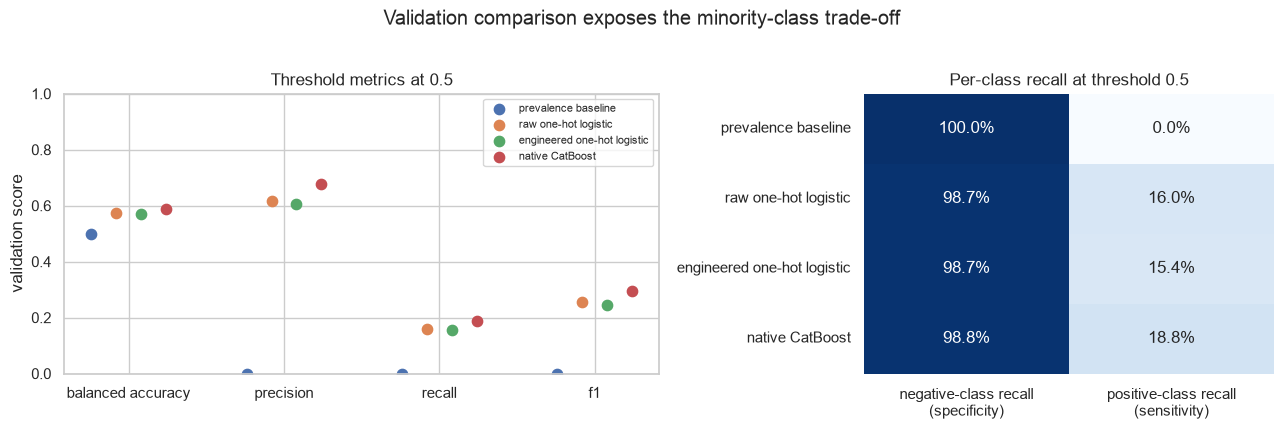

At threshold 0.5, native CatBoost has the highest balanced accuracy (0.588); its log loss is 0.286, precision is 0.677, and recall is 0.188.


In [14]:
from catboost import CatBoostClassifier
cat_columns = X_dev.select_dtypes(include="object").columns.tolist()
X_dev_cat, X_val_cat = X_dev.copy(), X_val.copy()
for c in cat_columns:
    X_dev_cat[c] = X_dev_cat[c].fillna("__MISSING__")
    X_val_cat[c] = X_val_cat[c].fillna("__MISSING__")

X_cat_fit, X_cat_stop, y_cat_fit, y_cat_stop = train_test_split(
    X_dev_cat, y_dev, test_size=0.15, stratify=y_dev, random_state=SEED
)

cat_stop_model = CatBoostClassifier(
    iterations=180 if FAST_MODE else 450, depth=6, learning_rate=0.06,
    loss_function="Logloss", eval_metric="Logloss", random_seed=SEED,
    verbose=False, allow_writing_files=False,
)
cat_stop_model.fit(X_cat_fit, y_cat_fit, cat_features=cat_columns,
                   eval_set=(X_cat_stop, y_cat_stop),
                   early_stopping_rounds=40, verbose=False)
best_iterations = cat_stop_model.get_best_iteration() + 1
cat_model = CatBoostClassifier(
    iterations=best_iterations, depth=6, learning_rate=0.06,
    loss_function="Logloss", random_seed=SEED,
    verbose=False, allow_writing_files=False,
)
cat_model.fit(X_dev_cat, y_dev, cat_features=cat_columns, verbose=False)
print(f"refit CatBoost on all development rows with {best_iterations} trees")

onehot_model = inspection_model
raw_onehot_model = baseline.fit(X_dev, y_dev)

def validation_metrics(y_true, probability, threshold=0.5):
    prediction = probability >= threshold
    return {
        "accuracy": accuracy_score(y_true, prediction),
        "balanced_accuracy": balanced_accuracy_score(y_true, prediction),
        "precision": precision_score(y_true, prediction, zero_division=0),
        "recall": recall_score(y_true, prediction, zero_division=0),
        "f1": f1_score(y_true, prediction, zero_division=0),
        "log_loss": log_loss(y_true, probability),
    }

validation_probabilities = {
    "prevalence baseline": np.full(len(y_val), y_dev.mean()),
    "raw one-hot logistic": raw_onehot_model.predict_proba(X_val)[:, 1],
    "engineered one-hot logistic": onehot_model.predict_proba(X_val)[:, 1],
    "native CatBoost": cat_model.predict_proba(X_val_cat)[:, 1],
}
comparison = pd.DataFrame({
    name: validation_metrics(y_val, probability)
    for name, probability in validation_probabilities.items()
}).T
display(comparison.style.format("{:.3f}"))

recall_rows = []
for name, probability in validation_probabilities.items():
    tn, fp, fn, tp = confusion_matrix(y_val, probability >= 0.5, labels=[0, 1]).ravel()
    recall_rows.append({
        "model": name,
        "negative-class recall\n(specificity)": tn / (tn + fp),
        "positive-class recall\n(sensitivity)": tp / (tp + fn),
    })
class_recall = pd.DataFrame(recall_rows).set_index("model")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2), gridspec_kw={"width_ratios": [1.45, 1]})
threshold_metrics_to_plot = ["balanced_accuracy", "precision", "recall", "f1"]
plot_comparison = comparison.loc[:, threshold_metrics_to_plot].rename(
    columns=lambda value: value.replace("_", " ")
)
x_positions = np.arange(len(plot_comparison.columns))
offsets = np.linspace(-0.24, 0.24, len(plot_comparison))
for offset, (model, row) in zip(offsets, plot_comparison.iterrows()):
    axes[0].scatter(x_positions + offset, row.values, s=55, label=model)
axes[0].set(xticks=x_positions, xticklabels=plot_comparison.columns,
            ylabel="validation score", ylim=(0, 1),
            title="Threshold metrics at 0.5")
axes[0].legend(fontsize=8, loc="best")
sns.heatmap(class_recall, annot=True, fmt=".1%", vmin=0, vmax=1, cmap="Blues",
            cbar=False, ax=axes[1])
axes[1].set(title="Per-class recall at threshold 0.5", xlabel="", ylabel="")
fig.suptitle("Validation comparison exposes the minority-class trade-off", y=1.02)
plt.tight_layout()
plt.show()

best_name = comparison["balanced_accuracy"].idxmax()
print(
    f"At threshold 0.5, {best_name} has the highest balanced accuracy "
    f"({comparison.loc[best_name, 'balanced_accuracy']:.3f}); "
    f"its log loss is {comparison.loc[best_name, 'log_loss']:.3f}, "
    f"precision is {comparison.loc[best_name, 'precision']:.3f}, and "
    f"recall is {comparison.loc[best_name, 'recall']:.3f}."
)

<div dir="rtl" style="text-align: right">

‏## Practical recommendation

‏Native categorical support is not automatically superior: it changes the model family as well as the encoding. A clean encoding comparison would hold the estimator and tuning budget fixed, which is not fully possible here. Treat this as a workflow comparison.

‏In the stored reduced-mode run, domain features do not improve overall accuracy, but they slightly improve recall, F1, and balanced accuracy. The fold-level changes are tiny, so the evidence is insufficient to claim that every engineered feature earns its added complexity.

‏A practical recommendation from this notebook is:

‏- Keep the raw one-hot logistic model as the maintainable baseline.
‏- Keep only engineered feature families that show repeatable cross-validation value or clear operational interpretability.
‏- Consider CatBoost when the team can support the dependency, training time, monitoring needs, and model-explanation workflow.
‏- Do not select a deployment threshold from this validation comparison. Threshold choice should come from business costs and should be finalized in a later, controlled evaluation.

‏The per-class recall view shows that every model still misses many subscribers at threshold `0.5`. That is a decision-policy question, not a reason to tune repeatedly on validation results.

‏## Common mistakes and leakage warnings

‏- Computing target means or category frequencies on all rows before cross-validation.
‏- Creating bins using full-data quantiles outside the pipeline.
‏- Treating `pdays=-1` as negative recency instead of a sentinel state.
‏- Densifying a large sparse one-hot matrix without checking memory.
‏- Keeping engineered features because they sound plausible despite weak ablation evidence.
‏- Reusing validation results for repeated feature selection, threshold selection, and final reporting.

‏## Exercises

‏1. Add cyclical month encoding and explain why chronology is still incomplete.
‏2. Replace fixed age bands with a spline (`SplineTransformer`) and compare it by cross-validation.
‏3. Plot fold-level accuracy and balanced-accuracy changes for each feature-family ablation.
‏4. Add a cost table where a false negative costs 5x a false positive, then choose a threshold using development data only.
‏5. **Challenge:** implement a scikit-learn-compatible transformer that learns rare categories during `fit` and maps them during `transform`; verify it with estimator checks and an unseen category.

‏## Summary

‏Feature engineering is safe when the prediction contract is explicit, row-wise logic is pure, and every learned transformation is fit inside cross-validation. Ablation, not narrative plausibility, decides whether a feature earns operational complexity.

‏## References

‏- [ColumnTransformer](https://scikit-learn.org/stable/modules/compose.html#column-transformer-for-heterogeneous-data)
‏- [OneHotEncoder](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OneHotEncoder.html)
‏- [Pipeline and composite estimators](https://scikit-learn.org/stable/modules/compose.html)
‏- [Common pitfalls and recommended practices](https://scikit-learn.org/stable/common_pitfalls.html)
‏- [Feature engineering chapter, scikit-learn MOOC](https://inria.github.io/scikit-learn-mooc/python_scripts/03_categorical_pipeline.html)
‏- [CatBoost categorical features](https://catboost.ai/en/docs/features/categorical-features)
‏- [CatBoost training algorithm](https://catboost.ai/docs/en/concepts/algorithm-main-stages)
‏- [How CatBoost transforms categorical features](https://catboost.ai/docs/en/concepts/algorithm-main-stages_cat-to-numberic)
‏- [CatBoost paper: unbiased boosting with categorical features](https://arxiv.org/abs/1706.09516)

</div>